# TFM

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import haversine_distances
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor

## 1. Carga de datos, análisis y limpieza.

In [91]:
# NODE 1 (LWAT01)
train_rssi   = pd.read_csv("LWAT01_trnrss.csv", header=None)
train_coords = pd.read_csv("LWAT01_trncrd.csv", header=None)

test_rssi    = pd.read_csv("LWAT01_tstrss.csv", header=None)
test_coords  = pd.read_csv("LWAT01_tstcrd.csv", header=None)

In [92]:
print("Muestras Train en 2018:", train_rssi.shape[0])
print("Muestras Test en 2018:", test_rssi.shape[0])
total = train_rssi.shape[0] + test_rssi.shape[0]
print("Total de muestras en la campaña de 2018:", total)
print("\n")
print("Número de gateways en 2018:", train_rssi.shape[1])
print("\n")
train_pct = train_rssi.shape[0] / total * 100
test_pct = test_rssi.shape[0] / total * 100
print(f"Porcentaje Train 2018: {train_pct:.2f}%")
print(f"Porcentaje Test 2018: {test_pct:.2f}%")

Muestras Train en 2018: 99231
Muestras Test en 2018: 24297
Total de muestras en la campaña de 2018: 123528


Número de gateways en 2018: 68


Porcentaje Train 2018: 80.33%
Porcentaje Test 2018: 19.67%


In [93]:
num_gateways = (train_rssi != -200).sum(axis=1)
num_gateways.value_counts()

3    91612
2     7514
1       92
6       10
5        3
Name: count, dtype: int64

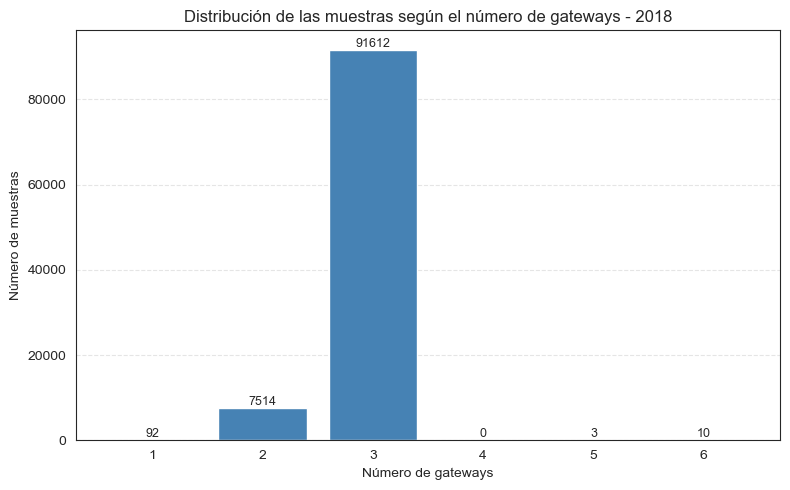

In [94]:
counts = num_gateways.value_counts().sort_index()
counts = counts.reindex(range(1, counts.index.max()+1), fill_value=0)

# Estilo limpio
sns.set_style("white")

plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color="steelblue")

plt.title("Distribución de las muestras según el número de gateways - 2018")
plt.xlabel("Número de gateways")
plt.ylabel("Número de muestras")

plt.xticks(counts.index)

plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [95]:
# Preparamos las variables de entrada y salida
X_train = train_rssi.fillna(-200)
X_test  = test_rssi.fillna(-200)
y_train = train_coords.iloc[:, :2]
y_test  = test_coords.iloc[:, :2]

# ignorar -200
min_rssi = X_train[X_train != -200].min().min()
tau = min_rssi - 1

# Tau lo usaremos para los valores señal 0 (No recibida o no consta)
print("min_rssi:", min_rssi)
print("tau:", tau)

min_rssi: -125.0
tau: -126.0


In [96]:
# Procesaremso los datos de tres formas distintas segun lo explican en el articulo

def preprocess_rssi_base(X, tau):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Normalization [0,1]
    X = X / X.max().max()
    return X

def preprocess_rssi_exponential(X, tau, alpha=60):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Exponencial
    X = np.exp(X / alpha) / np.exp(-tau / alpha)
    return X

def preprocess_rssi_power(X, tau, beta=1.1):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Power
    X = (X ** beta) / ((-tau) ** beta)
    return X

In [97]:
X_train_base = preprocess_rssi_base(X_train, tau)
X_test_base  = preprocess_rssi_base(X_test, tau)

X_train_pow = preprocess_rssi_power(X_train, tau)
X_test_pow  = preprocess_rssi_power(X_test, tau)

X_train_exp = preprocess_rssi_exponential(X_train, tau)
X_test_exp  = preprocess_rssi_exponential(X_test, tau)

In [98]:
scaler_y = StandardScaler()
y_train_scaled = pd.DataFrame(
    scaler_y.fit_transform(y_train),
    index=y_train.index,
    columns=y_train.columns)

## KNN

### BASE

#### Sin weights='distance'

In [10]:
param_grid = {'n_neighbors': list(range(1, 20))}
knn = KNeighborsRegressor(metric='braycurtis')

grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

start = time.time()
grid_knn.fit(X_train_base, y_train_scaled)
# Guardamos los resultados en un dataframe
result_grid = pd.DataFrame(grid_knn.cv_results_)
end = time.time()
best_k = grid_knn.best_params_['n_neighbors']
print(f"Valor óptimo de k: {best_k}")
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 5 folds for each of 19 candidates, totalling 95 fits
Valor óptimo de k: 17
Tiempo total: 1047.12 segundos


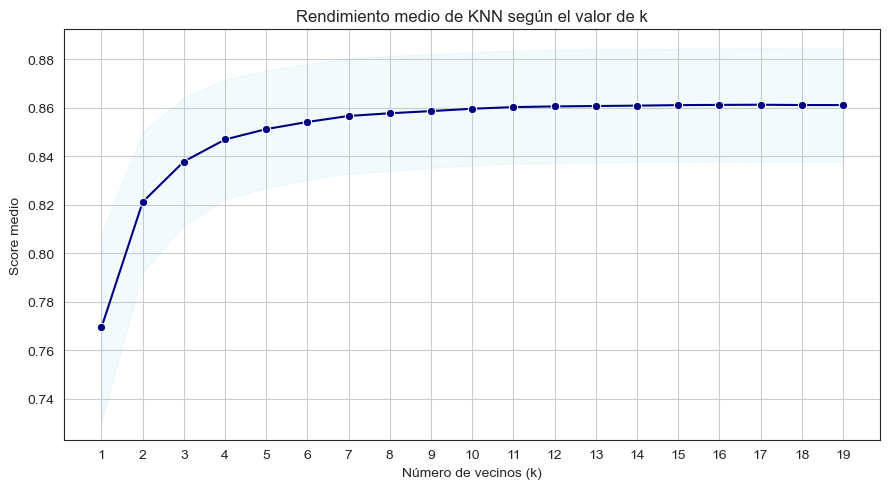

In [11]:
# Representamos visualmente la precisión media de KNN según el valor de k
# Almacenamos los k, las medias y las desviaciones estándar
k_values = result_grid['param_n_neighbors']
mean_acc = result_grid['mean_test_score']
std_acc = result_grid['std_test_score']

plt.figure(figsize=(9,5))
# Línea principal
sns.lineplot(x=k_values, y=mean_acc, marker='o', color='navy')
# Banda de desviación estándar
plt.fill_between(k_values, mean_acc - std_acc, mean_acc + std_acc, alpha=0.1, color='skyblue')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Score medio')
plt.title('Rendimiento medio de KNN según el valor de k')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

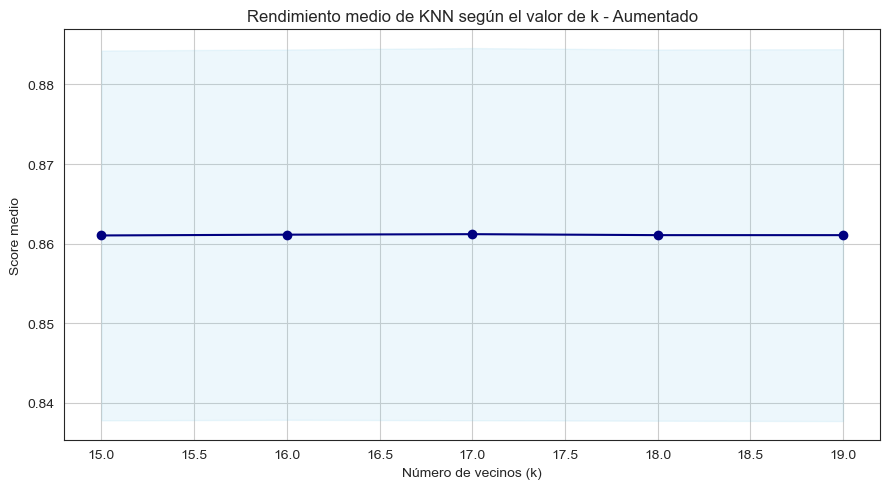

In [12]:
mask = (k_values >= 15) & (k_values <= 20)

plt.figure(figsize=(9,5))
plt.plot(k_values[mask], mean_acc[mask], marker='o', color='navy')
plt.fill_between(
    k_values[mask],
    mean_acc[mask] - std_acc[mask],
    mean_acc[mask] + std_acc[mask],
    alpha=0.15,
    color='skyblue'
)
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Score medio')
plt.title('Rendimiento medio de KNN según el valor de k - Aumentado')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
knn_opt = KNeighborsRegressor(n_neighbors=best_k, metric='braycurtis')
knn_opt.fit(X_train_base, y_train_scaled)

,n_neighbors,17
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'braycurtis'
,metric_params,None
,n_jobs,None


In [14]:
start = time.time()

# TRAIN

y_train_pred_scaled = knn_opt.predict(X_train_base)
y_train_pred_knn = scaler_y.inverse_transform(y_train_pred_scaled)

# Pasamos a radianes para usar haversine_distances
y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_knn[:, [1, 0]])

# Calculamos la distancia angular entre los puntos y multiplicamos por el radio de la tierra para tener los valores reales
dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))   # bucle para tomar solo lo que serían los datos de la diagonal
]) * 6371000

print('TRAIN:')
print(f"KNN Mean: {dist_train.mean():.2f}")
print(f"KNN Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = knn_opt.predict(X_test_base)
y_test_pred_knn = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_knn[:, [1, 0]])

dist_test_knn1 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('TEST:')
print(f"KNN Mean: {dist_test_knn1.mean():.2f}")
print(f"KNN Median: {np.median(dist_test_knn1):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
KNN Mean: 353.93
KNN Median: 238.07
TEST:
KNN Mean: 469.37
KNN Median: 332.04
Tiempo total: 173.39 segundos


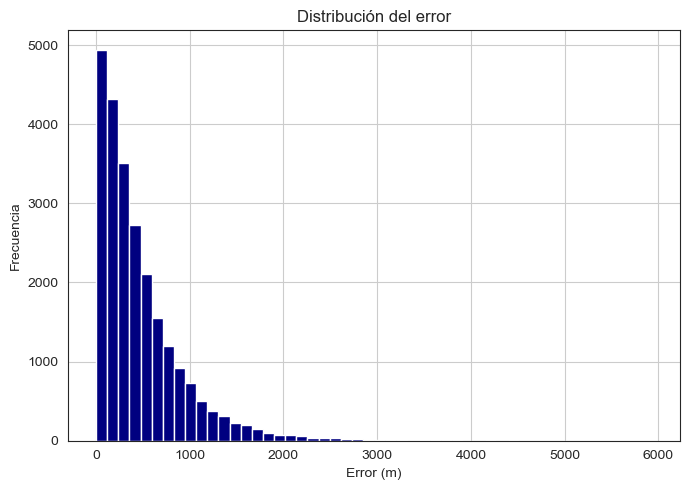

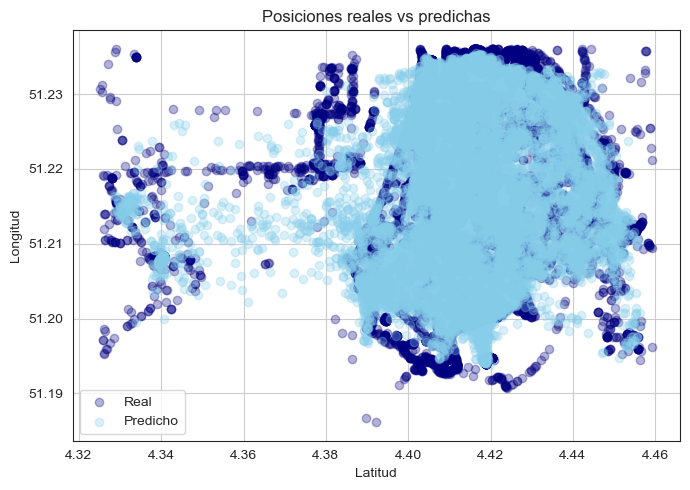

In [15]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_knn1, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Con weights='distance'

In [16]:
param_grid = {'n_neighbors': list(range(1, 30))}
knn = KNeighborsRegressor(metric='braycurtis', weights='distance')

grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

start = time.time()
grid_knn.fit(X_train_base, y_train_scaled)
# Guardamos los resultados en un dataframe
result_grid = pd.DataFrame(grid_knn.cv_results_)
end = time.time()
best_k = grid_knn.best_params_['n_neighbors']
print(f"Valor óptimo de k: {best_k}")
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 5 folds for each of 29 candidates, totalling 145 fits
Valor óptimo de k: 25
Tiempo total: 1684.45 segundos


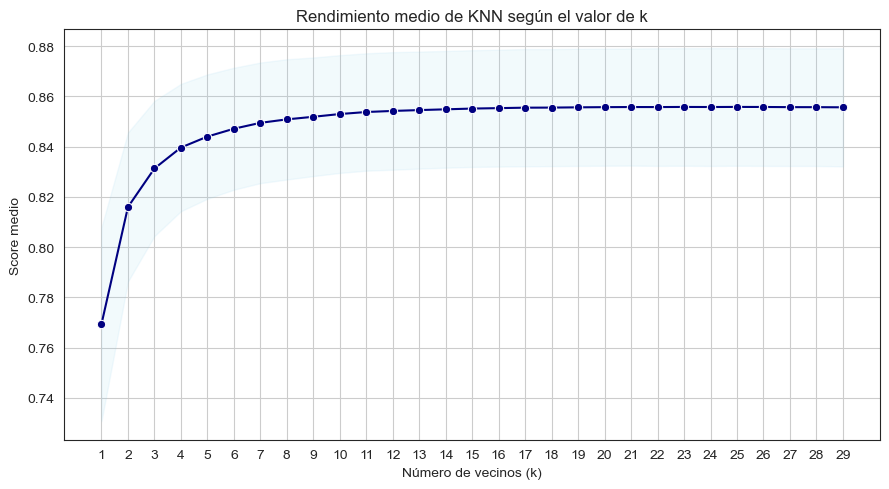

In [17]:
# Representamos visualmente la precisión media de KNN según el valor de k
# Almacenamos los k, las medias y las desviaciones estándar
k_values = result_grid['param_n_neighbors']
mean_acc = result_grid['mean_test_score']
std_acc = result_grid['std_test_score']

plt.figure(figsize=(9,5))
# Línea principal
sns.lineplot(x=k_values, y=mean_acc, marker='o', color='navy')
# Banda de desviación estándar
plt.fill_between(k_values, mean_acc - std_acc, mean_acc + std_acc, alpha=0.1, color='skyblue')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Score medio')
plt.title('Rendimiento medio de KNN según el valor de k')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

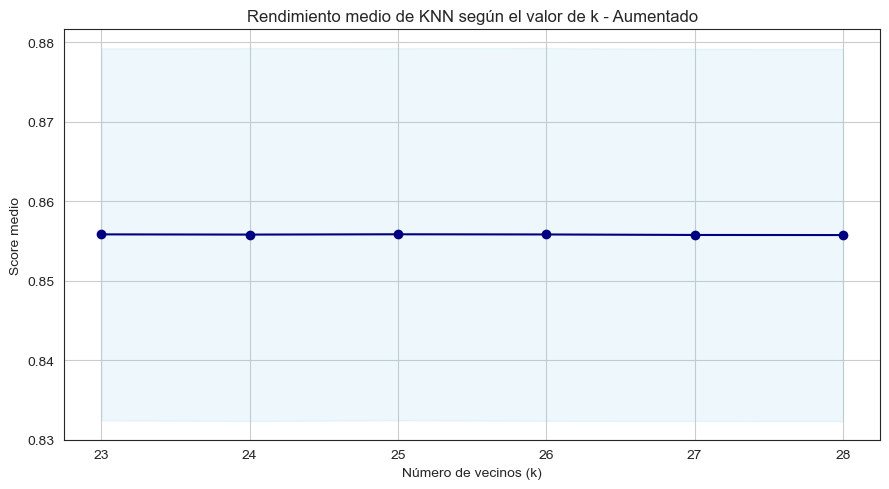

In [18]:
mask = (k_values >= 23) & (k_values <= 28)

plt.figure(figsize=(9,5))
plt.plot(k_values[mask], mean_acc[mask], marker='o', color='navy')
plt.fill_between(
    k_values[mask],
    mean_acc[mask] - std_acc[mask],
    mean_acc[mask] + std_acc[mask],
    alpha=0.15,
    color='skyblue'
)
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Score medio')
plt.title('Rendimiento medio de KNN según el valor de k - Aumentado')
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
knn_opt = KNeighborsRegressor(n_neighbors=best_k, metric='braycurtis', weights='distance')
knn_opt.fit(X_train_base, y_train_scaled)

,n_neighbors,25
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'braycurtis'
,metric_params,None
,n_jobs,None


In [20]:
start = time.time()

# TRAIN

y_train_pred_scaled = knn_opt.predict(X_train_base)
y_train_pred_knn = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_knn[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"KNN Mean: {dist_train.mean():.2f}")
print(f"KNN Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = knn_opt.predict(X_test_base)
y_test_pred_knn = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_knn[:, [1, 0]])

dist_test_knn2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('TEST:')
print(f"KNN Mean: {dist_test_knn2.mean():.2f}")
print(f"KNN Median: {np.median(dist_test_knn2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
KNN Mean: 37.78
KNN Median: 0.00
TEST:
KNN Mean: 465.21
KNN Median: 329.02
Tiempo total: 173.00 segundos


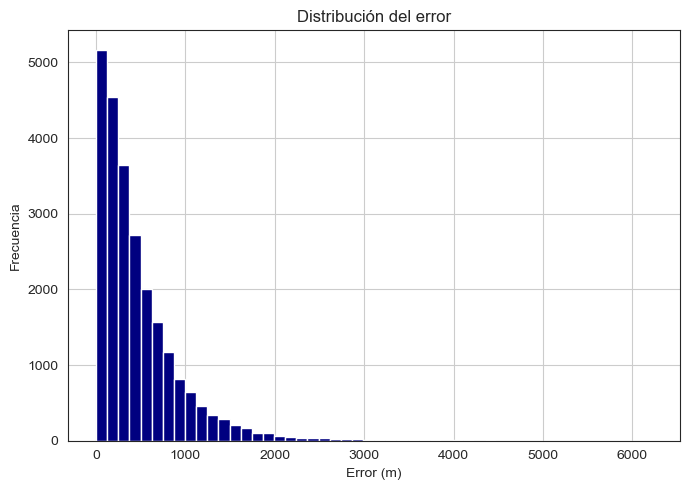

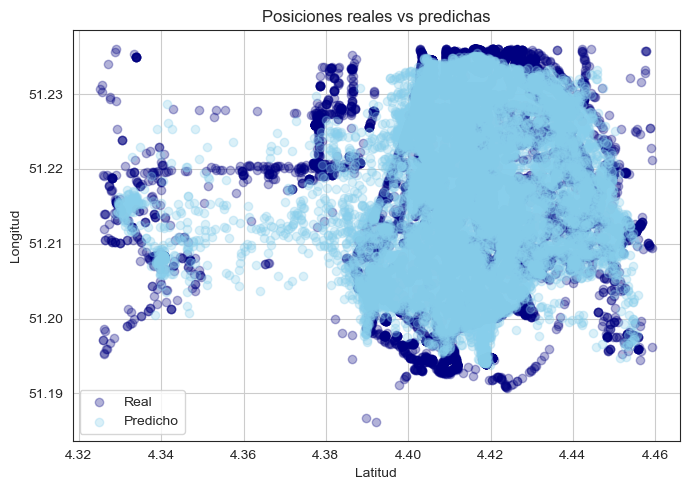

In [21]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_knn2, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### POW

#### Sin weights='distance'

In [22]:
start = time.time()

param_grid = {'n_neighbors': list(range(15, 20))}
knn = KNeighborsRegressor(metric='braycurtis')

grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

grid_knn.fit(X_train_pow, y_train_scaled)
best_k = grid_knn.best_params_['n_neighbors']
print(f"Valor óptimo de k: {best_k}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Valor óptimo de k: 17
Tiempo total: 328.94 segundos


In [23]:
knn_opt_pow = KNeighborsRegressor(n_neighbors=best_k, metric='braycurtis')
knn_opt_pow.fit(X_train_pow, y_train_scaled)

,n_neighbors,17
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'braycurtis'
,metric_params,None
,n_jobs,None


In [24]:
start = time.time()

# TRAIN

y_train_pred_scaled = knn_opt_pow.predict(X_train_pow)
y_train_pred_knn = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_knn[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"KNN Mean: {dist_train.mean():.2f}")
print(f"KNN Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = knn_opt_pow.predict(X_test_pow)
y_test_pred_knn = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_knn[:, [1, 0]])

dist_test_knn3 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"KNN Mean: {dist_test_knn3.mean():.2f}")
print(f"KNN Median: {np.median(dist_test_knn3):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
KNN Mean: 353.56
KNN Median: 238.07

TEST:
KNN Mean: 461.45
KNN Median: 323.20
Tiempo total: 172.00 segundos


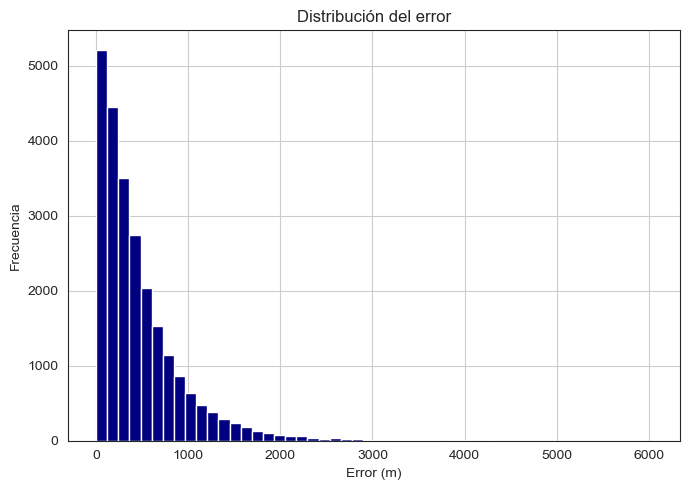

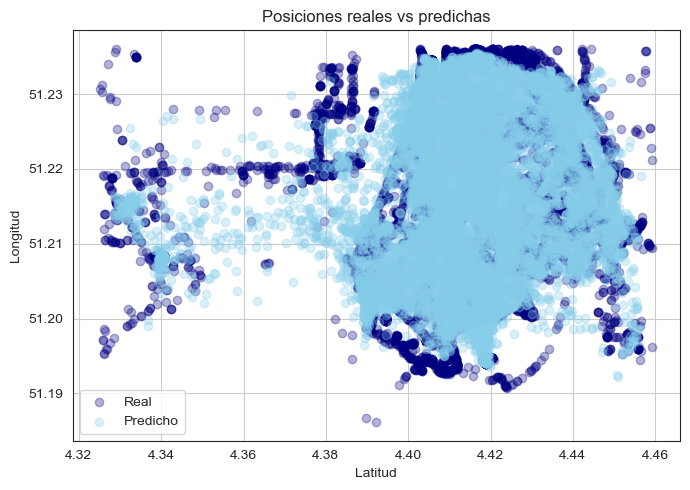

In [25]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_knn3, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Con weights='distance'

In [26]:
start = time.time()

param_grid = {'n_neighbors': list(range(20, 28))}
knn = KNeighborsRegressor(metric='braycurtis', weights='distance')

grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

grid_knn.fit(X_train_pow, y_train_scaled)
best_k = grid_knn.best_params_['n_neighbors']
print(f"Valor óptimo de k: {best_k}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Valor óptimo de k: 22
Tiempo total: 502.75 segundos


In [27]:
knn_opt_pow = KNeighborsRegressor(n_neighbors=best_k, metric='braycurtis', weights='distance')
knn_opt_pow.fit(X_train_pow, y_train_scaled)

,n_neighbors,22
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'braycurtis'
,metric_params,None
,n_jobs,None


In [28]:
start = time.time()

# TRAIN

y_train_pred_scaled = knn_opt_pow.predict(X_train_pow)
y_train_pred_knn = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_knn[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"KNN Mean: {dist_train.mean():.2f}")
print(f"KNN Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = knn_opt_pow.predict(X_test_pow)
y_test_pred_knn = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_knn[:, [1, 0]])

dist_test_knn4 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"KNN Mean: {dist_test_knn4.mean():.2f}")
print(f"KNN Median: {np.median(dist_test_knn4):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
KNN Mean: 37.78
KNN Median: 0.00

TEST:
KNN Mean: 468.84
KNN Median: 326.97
Tiempo total: 172.32 segundos


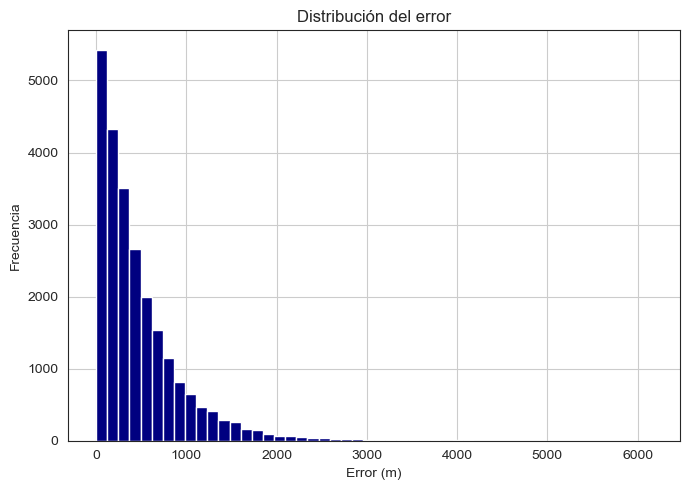

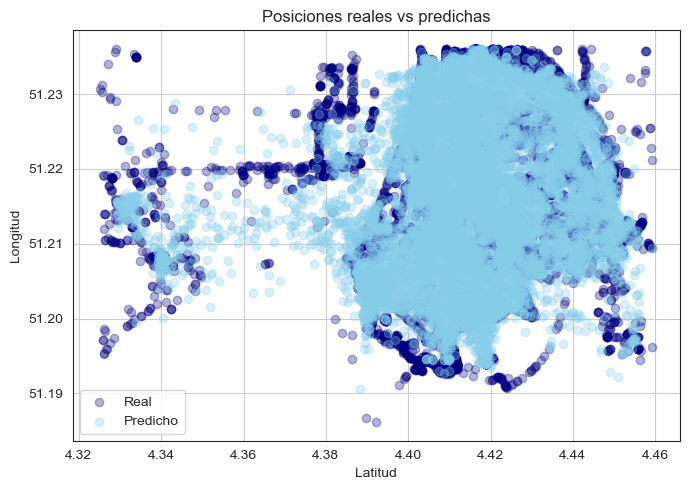

In [29]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_knn4, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### EXP

#### Sin weights='distance'

In [30]:
start = time.time()

param_grid = {'n_neighbors': list(range(15, 20))}
knn = KNeighborsRegressor(metric='braycurtis')

grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

grid_knn.fit(X_train_exp, y_train_scaled)
best_k = grid_knn.best_params_['n_neighbors']
print(f"Valor óptimo de k: {best_k}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Valor óptimo de k: 18
Tiempo total: 331.20 segundos


In [31]:
knn_opt_exp = KNeighborsRegressor(n_neighbors=best_k, metric='braycurtis')
knn_opt_exp.fit(X_train_exp, y_train_scaled)

,n_neighbors,18
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'braycurtis'
,metric_params,None
,n_jobs,None


In [32]:
start = time.time()

# TRAIN

y_train_pred_scaled = knn_opt_exp.predict(X_train_exp)
y_train_pred_knn = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_knn[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"KNN Mean: {dist_train.mean():.2f}")
print(f"KNN Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = knn_opt_exp.predict(X_test_exp)
y_test_pred_knn = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_knn[:, [1, 0]])

dist_test_knn5 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"KNN Mean: {dist_test_knn5.mean():.2f}")
print(f"KNN Median: {np.median(dist_test_knn5):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
KNN Mean: 358.09
KNN Median: 241.87

TEST:
KNN Mean: 466.53
KNN Median: 328.19
Tiempo total: 173.68 segundos


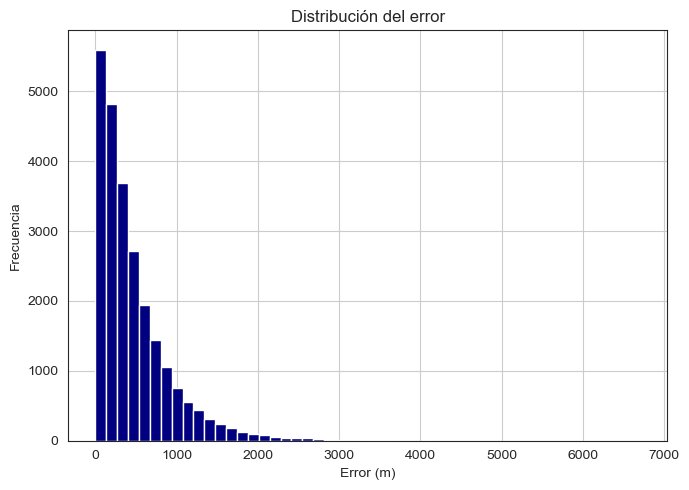

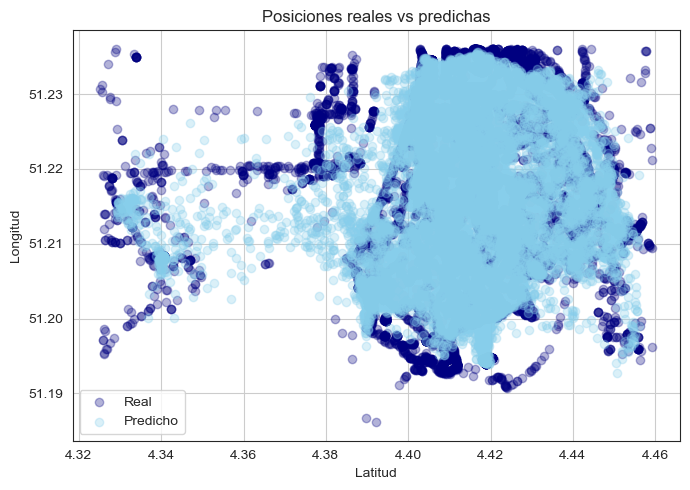

In [33]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_knn5, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Con weights='distance'

In [99]:
start = time.time()

param_grid = {'n_neighbors': list(range(17, 22))}
knn = KNeighborsRegressor(metric='braycurtis', weights='distance')

grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

grid_knn.fit(X_train_exp, y_train_scaled)
best_k = grid_knn.best_params_['n_neighbors']
print(f"Valor óptimo de k: {best_k}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Valor óptimo de k: 18
Tiempo total: 416.77 segundos


In [100]:
knn_opt_exp = KNeighborsRegressor(n_neighbors=best_k, metric='braycurtis', weights='distance')
knn_opt_exp.fit(X_train_exp, y_train_scaled)

,n_neighbors,18
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'braycurtis'
,metric_params,None
,n_jobs,None


In [101]:
start = time.time()

# TRAIN

y_train_pred_scaled = knn_opt_exp.predict(X_train_exp)
y_train_pred_knn = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_knn[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"KNN Mean: {dist_train.mean():.2f}")
print(f"KNN Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = knn_opt_exp.predict(X_test_exp)
y_test_pred_knn = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_knn[:, [1, 0]])

dist_test_knn6 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"KNN Mean: {dist_test_knn6.mean():.2f}")
print(f"KNN Median: {np.median(dist_test_knn6):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
KNN Mean: 37.78
KNN Median: 0.00

TEST:
KNN Mean: 472.82
KNN Median: 330.25
Tiempo total: 220.96 segundos


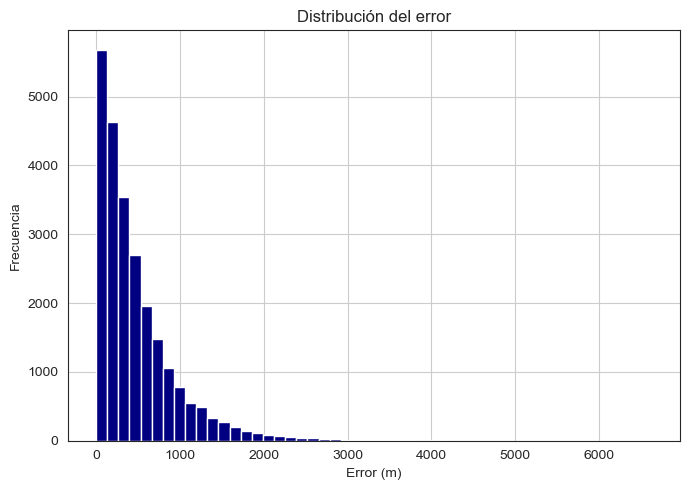

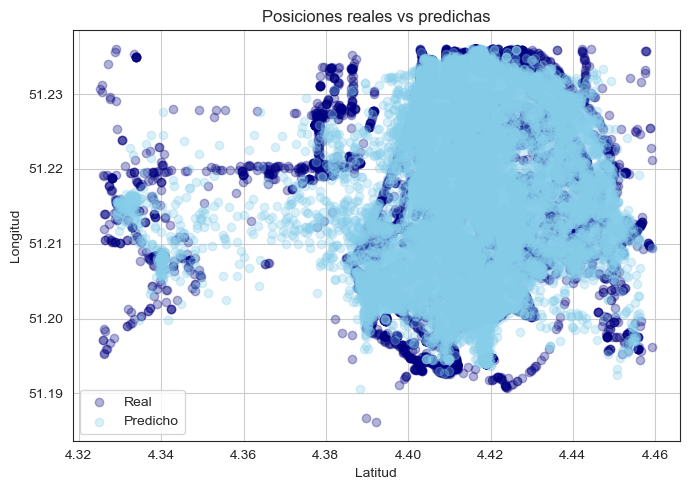

In [102]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_knn6, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Métodos basados en árboles de decisión

### Random Forest

#### BASE

In [38]:
start = time.time()
# Definimos el modelo
rfr = RandomForestRegressor(random_state=42, n_jobs=-1)
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [30, 40, 50],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_rfr = GridSearchCV(
    rfr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_rfr.fit(X_train_base, y_train_scaled)

best_params = grid_rfr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 150}
Tiempo total: 875.11 segundos


In [39]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']

# Entrenamos con la mejor combinación de parámetros
rfr_opt = RandomForestRegressor(n_estimators=best_n_estimators,
                                max_depth=best_max_depth,
                                min_samples_split=best_min_samples_split,
                                min_samples_leaf=best_min_samples_leaf,
                                random_state=42,
                                n_jobs=-1)
rfr_opt.fit(X_train_base, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 7.95 segundos


In [40]:
start = time.time()

# TRAIN

y_train_pred_scaled = rfr_opt.predict(X_train_base)
y_train_pred_rfr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_rfr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"RandomForest Mean: {dist_train.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = rfr_opt.predict(X_test_base)
y_test_pred_rfr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_rfr[:, [1, 0]])

dist_test_rfr1 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"RandomForest Mean: {dist_test_rfr1.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_test_rfr1):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
RandomForest Mean: 305.39
RandomForest Median: 215.16

TEST:
RandomForest Mean: 476.12
RandomForest Median: 334.94
Tiempo total: 23.90 segundos


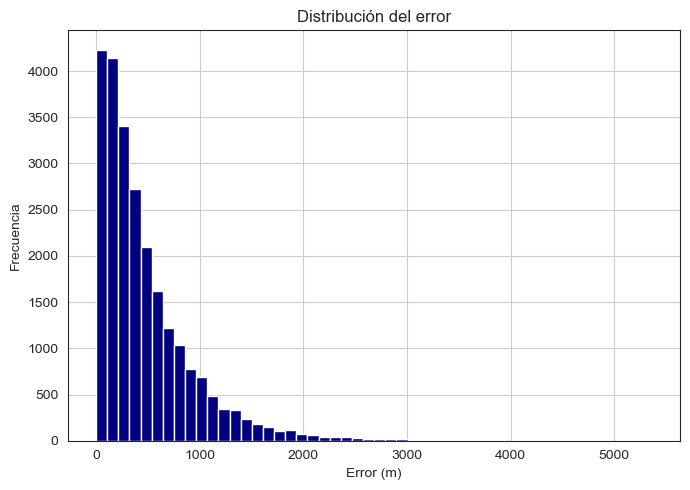

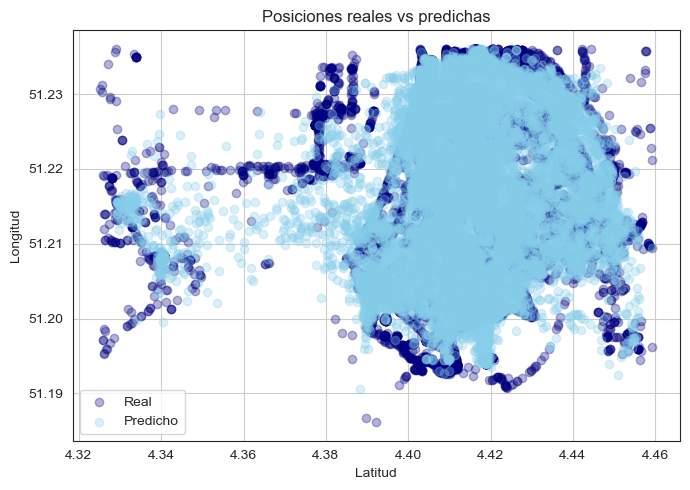

In [41]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_rfr1, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### POW

In [42]:
start = time.time()
# Definimos el modelo
rfr = RandomForestRegressor(random_state=42, n_jobs=-1)
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [30, 40, 50],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_rfr = GridSearchCV(
    rfr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_rfr.fit(X_train_pow, y_train_scaled)

best_params = grid_rfr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 150}
Tiempo total: 867.61 segundos


In [43]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']

# Entrenamos con la mejor combinación de parámetros
rfr_opt = RandomForestRegressor(n_estimators=best_n_estimators,
                                max_depth=best_max_depth,
                                min_samples_split=best_min_samples_split,
                                min_samples_leaf=best_min_samples_leaf,
                                random_state=42,
                                n_jobs=-1)
rfr_opt.fit(X_train_pow, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 7.42 segundos


In [44]:
start = time.time()

# TRAIN

y_train_pred_scaled = rfr_opt.predict(X_train_pow)
y_train_pred_rfr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_rfr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"RandomForest Mean: {dist_train.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = rfr_opt.predict(X_test_pow)
y_test_pred_rfr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_rfr[:, [1, 0]])

dist_test_rfr2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"RandomForest Mean: {dist_test_rfr2.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_test_rfr2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
RandomForest Mean: 305.40
RandomForest Median: 215.10

TEST:
RandomForest Mean: 467.55
RandomForest Median: 326.00
Tiempo total: 22.86 segundos


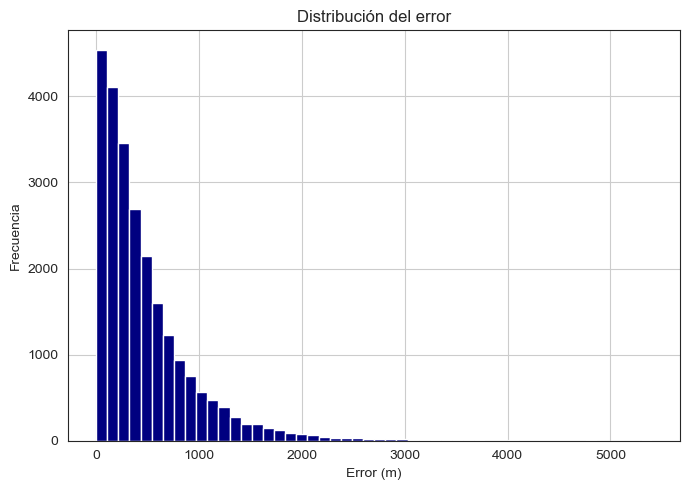

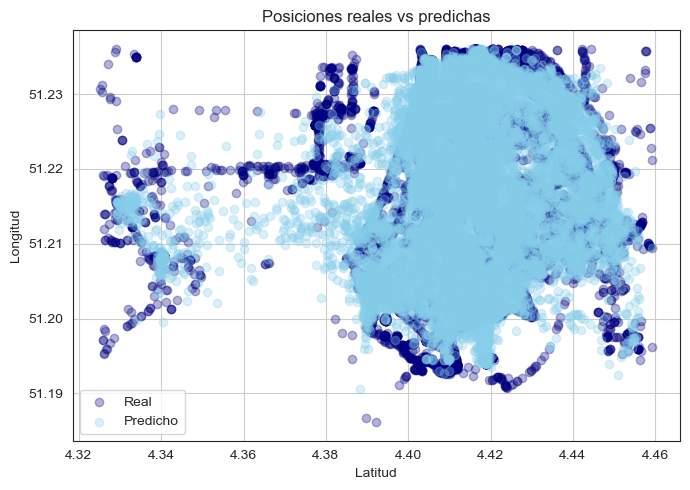

In [45]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_rfr2, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### EXP

In [46]:
start = time.time()
# Definimos el modelo
rfr = RandomForestRegressor(random_state=42, n_jobs=-1)
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [30, 40, 50],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_rfr = GridSearchCV(
    rfr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_rfr.fit(X_train_exp, y_train_scaled)

best_params = grid_rfr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 150}
Tiempo total: 870.56 segundos


In [47]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']

# Entrenamos con la mejor combinación de parámetros
rfr_opt = RandomForestRegressor(n_estimators=best_n_estimators,
                                max_depth=best_max_depth,
                                min_samples_split=best_min_samples_split,
                                min_samples_leaf=best_min_samples_leaf,
                                random_state=42,
                                n_jobs=-1)
rfr_opt.fit(X_train_exp, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 7.93 segundos


In [48]:
start = time.time()

# TRAIN

y_train_pred_scaled = rfr_opt.predict(X_train_exp)
y_train_pred_rfr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_rfr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"RandomForest Mean: {dist_train.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = rfr_opt.predict(X_test_exp)
y_test_pred_rfr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_rfr[:, [1, 0]])

dist_test_rfr3 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"RandomForest Mean: {dist_test_rfr3.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_test_rfr3):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
RandomForest Mean: 305.40
RandomForest Median: 215.10

TEST:
RandomForest Mean: 467.53
RandomForest Median: 325.92
Tiempo total: 23.57 segundos


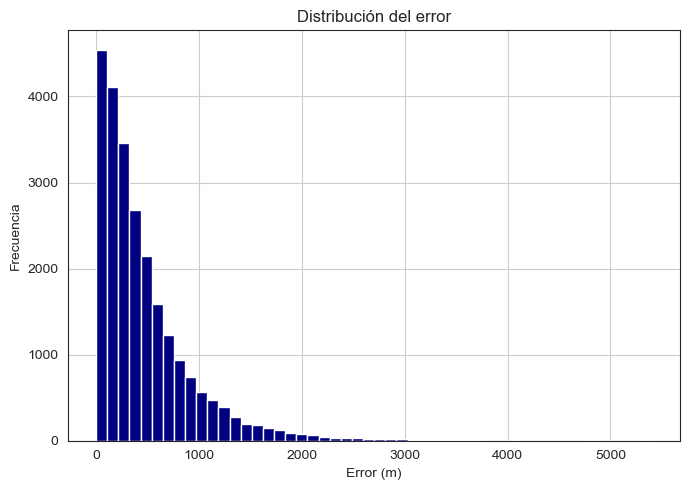

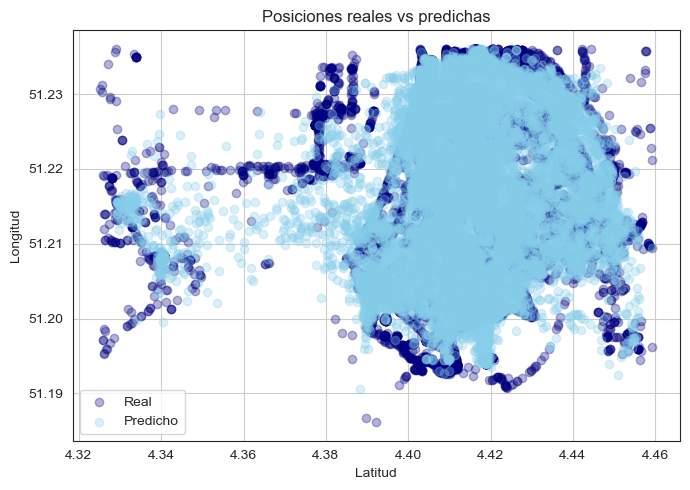

In [49]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_rfr3, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Extra Trees

#### BASE

In [50]:
#X_small = X_train_base.sample(50000, random_state=42)
#y_small = y_train_scaled.loc[X_small.index]

In [51]:
start = time.time()
# Definimos el modelo
etr = ExtraTreesRegressor(random_state=42, n_jobs=-1)
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [30, 40, 50],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_etr = GridSearchCV(
    etr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_etr.fit(X_train_base, y_train_scaled)
#grid_etr.fit(X_small, y_small)
best_params = grid_etr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 150}
Tiempo total: 1146.98 segundos


In [52]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']

# Entrenamos con la mejor combinación de parámetros
etr_opt = ExtraTreesRegressor(n_estimators=best_n_estimators,
                              max_depth=best_max_depth,
                              min_samples_split=best_min_samples_split,
                              min_samples_leaf=best_min_samples_leaf,
                              random_state=42,
                              n_jobs=-1)
etr_opt.fit(X_train_base, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 8.84 segundos


In [53]:
start = time.time()

# TRAIN

y_train_pred_scaled = etr_opt.predict(X_train_base)
y_train_pred_etr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_etr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"ExtraTrees Mean: {dist_train.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = etr_opt.predict(X_test_base)
y_test_pred_etr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_etr[:, [1, 0]])

dist_test_etr1 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"ExtraTrees Mean: {dist_test_etr1.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_test_etr1):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
ExtraTrees Mean: 294.63
ExtraTrees Median: 208.57

TEST:
ExtraTrees Mean: 466.75
ExtraTrees Median: 335.08
Tiempo total: 22.85 segundos


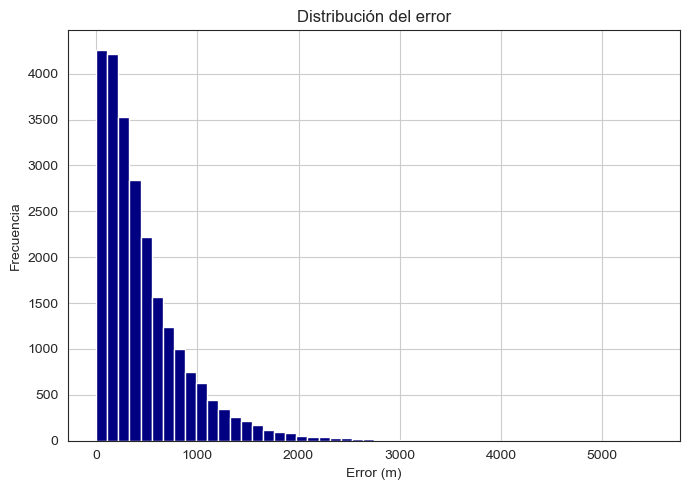

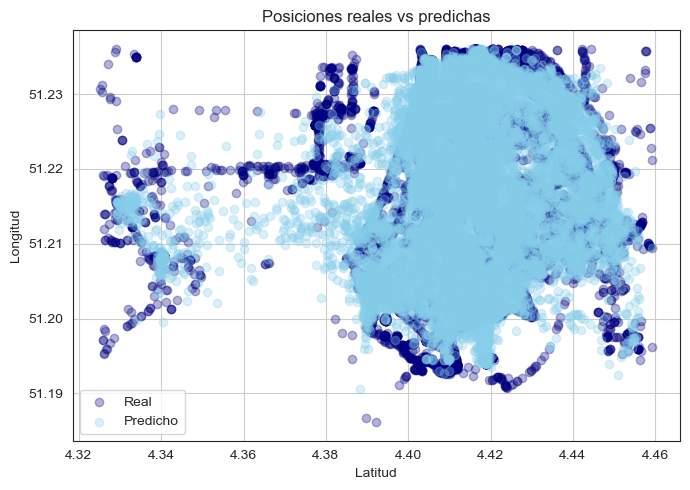

In [54]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_etr1, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### POW

In [55]:
#X_small = X_train_pow.sample(50000, random_state=42)
#y_small = y_train_scaled.loc[X_small.index]

In [56]:
start = time.time()
# Definimos el modelo
etr = ExtraTreesRegressor(random_state=42, n_jobs=-1)
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [30, 40, 50],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_etr = GridSearchCV(
    etr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_etr.fit(X_train_base, y_train_scaled)
#grid_etr.fit(X_small, y_small)
best_params = grid_etr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 150}
Tiempo total: 1146.87 segundos


In [57]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']

# Entrenamos con la mejor combinación de parámetros
etr_opt = ExtraTreesRegressor(n_estimators=best_n_estimators,
                              max_depth=best_max_depth,
                              min_samples_split=best_min_samples_split,
                              min_samples_leaf=best_min_samples_leaf,
                              random_state=42,
                              n_jobs=-1)
etr_opt.fit(X_train_pow, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 8.67 segundos


In [58]:
start = time.time()

# TRAIN

y_train_pred_scaled = etr_opt.predict(X_train_pow)
y_train_pred_etr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_etr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"ExtraTrees Mean: {dist_train.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = etr_opt.predict(X_test_pow)
y_test_pred_etr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_etr[:, [1, 0]])

dist_test_etr2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"ExtraTrees Mean: {dist_test_etr2.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_test_etr2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
ExtraTrees Mean: 294.32
ExtraTrees Median: 209.02

TEST:
ExtraTrees Mean: 459.17
ExtraTrees Median: 324.19
Tiempo total: 21.73 segundos


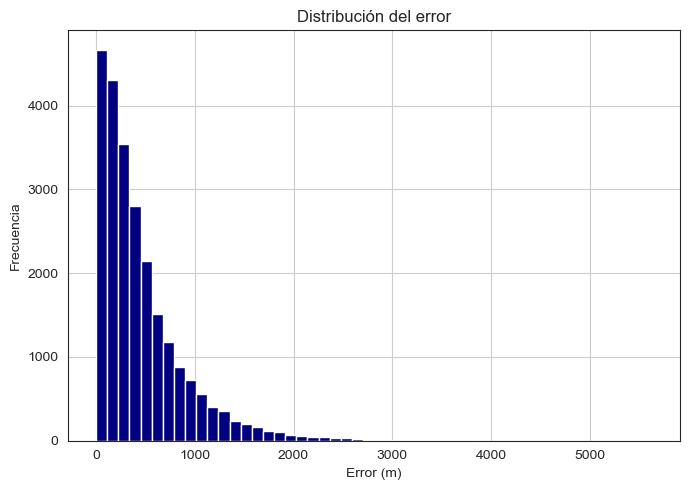

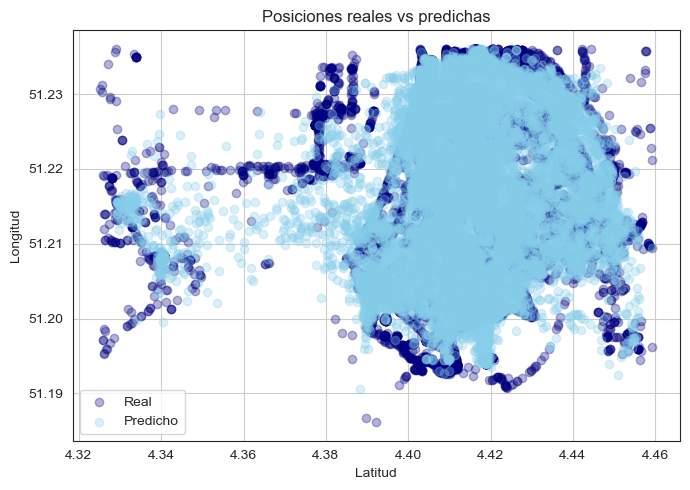

In [59]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_etr2, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### EXP

In [60]:
#X_small = X_train_exp.sample(50000, random_state=42)
#y_small = y_train_scaled.loc[X_small.index]

In [61]:
start = time.time()
# Definimos el modelo
etr = ExtraTreesRegressor(random_state=42, n_jobs=-1)
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [30, 40, 50],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_etr = GridSearchCV(
    etr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_etr.fit(X_train_base, y_train_scaled)
#grid_etr.fit(X_small, y_small)
best_params = grid_etr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 150}
Tiempo total: 1146.13 segundos


In [62]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']

# Entrenamos con la mejor combinación de parámetros
etr_opt = ExtraTreesRegressor(n_estimators=best_n_estimators,
                              max_depth=best_max_depth,
                              min_samples_split=best_min_samples_split,
                              min_samples_leaf=best_min_samples_leaf,
                              random_state=42,
                              n_jobs=-1)
etr_opt.fit(X_train_exp, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 9.31 segundos


In [63]:
start = time.time()

# TRAIN

y_train_pred_scaled = etr_opt.predict(X_train_exp)
y_train_pred_etr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_etr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"ExtraTrees Mean: {dist_train.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = etr_opt.predict(X_test_exp)
y_test_pred_etr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_etr[:, [1, 0]])

dist_test_etr3 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"ExtraTrees Mean: {dist_test_etr3.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_test_etr3):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
ExtraTrees Mean: 294.68
ExtraTrees Median: 209.09

TEST:
ExtraTrees Mean: 459.45
ExtraTrees Median: 324.04
Tiempo total: 21.81 segundos


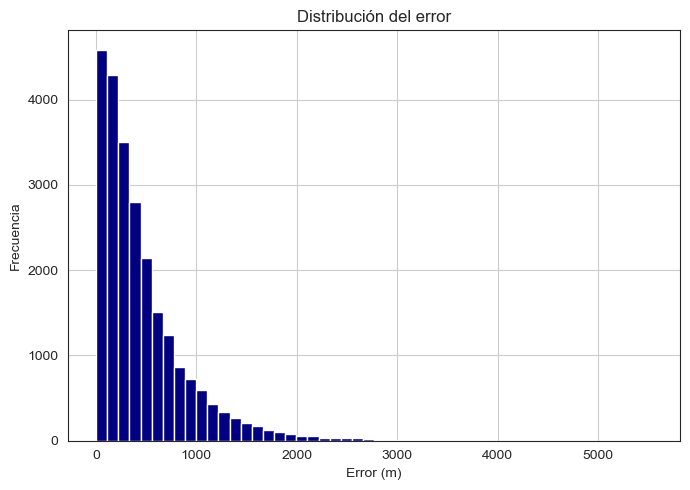

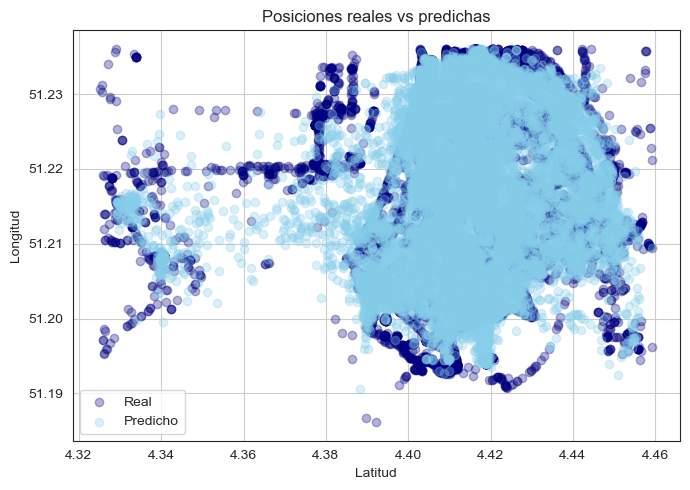

In [64]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_etr3, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Gradient Boosting

#### BASE

In [65]:
start = time.time()
# Definimos el modelo
gbr = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'estimator__n_estimators': [100, 150, 200],
    'estimator__learning_rate': [0.05, 0.7],
    'estimator__max_depth': [9, 11, 13],
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_gbr = GridSearchCV(
    gbr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_gbr.fit(X_train_base, y_train_scaled)

best_params = grid_gbr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'estimator__learning_rate': 0.05, 'estimator__max_depth': 11, 'estimator__n_estimators': 200}
Tiempo total: 769.76 segundos


In [66]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['estimator__n_estimators']
best_learning_rate = best_params['estimator__learning_rate']
best_max_depth = best_params['estimator__max_depth']

# Entrenamos con la mejor combinación de parámetros
gbr_opt = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42))
gbr_opt.fit(X_train_base, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 171.20 segundos


In [67]:
start = time.time()

# TRAIN

y_train_pred_scaled = gbr_opt.predict(X_train_base)
y_train_pred_gbr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_gbr[:, [1, 0]])

dist_train = np.array([
    haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000
#dist_train = haversine_distances(y_true_train_rad, y_pred_train_rad).diagonal() * 6371000

print('TRAIN:')
print(f"GradientBoosting Mean: {dist_train.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = gbr_opt.predict(X_test_base)
y_test_pred_gbr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_gbr[:, [1, 0]])

dist_test_gbr1 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"GradientBoosting Mean: {dist_test_gbr1.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_test_gbr1):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
GradientBoosting Mean: 344.47
GradientBoosting Median: 256.19

TEST:
GradientBoosting Mean: 483.86
GradientBoosting Median: 357.20
Tiempo total: 22.85 segundos


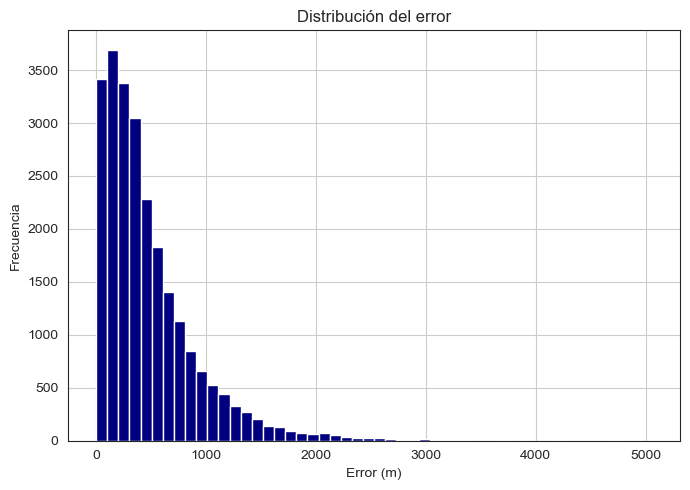

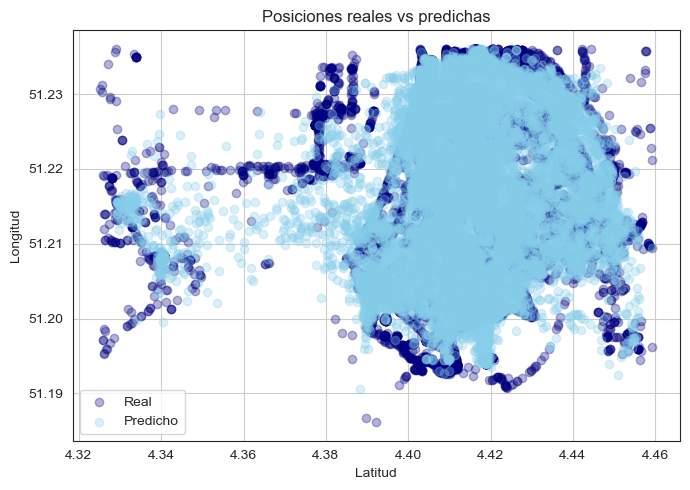

In [68]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_gbr1, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### POW

In [69]:
start = time.time()
# Definimos el modelo
gbr = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'estimator__n_estimators': [100, 150, 200],
    'estimator__learning_rate': [0.05, 0.7],
    'estimator__max_depth': [9, 11, 13],
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_gbr = GridSearchCV(
    gbr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_gbr.fit(X_train_pow, y_train_scaled)

best_params = grid_gbr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'estimator__learning_rate': 0.05, 'estimator__max_depth': 11, 'estimator__n_estimators': 200}
Tiempo total: 834.62 segundos


In [70]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['estimator__n_estimators']
best_learning_rate = best_params['estimator__learning_rate']
best_max_depth = best_params['estimator__max_depth']

# Entrenamos con la mejor combinación de parámetros
gbr_opt = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42))
gbr_opt.fit(X_train_pow, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 171.92 segundos


In [71]:
start = time.time()

# TRAIN

y_train_pred_scaled = gbr_opt.predict(X_train_pow)
y_train_pred_gbr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_gbr[:, [1, 0]])

dist_train = np.array([
    haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000
#dist_train = haversine_distances(y_true_train_rad, y_pred_train_rad).diagonal() * 6371000

print('TRAIN:')
print(f"GradientBoosting Mean: {dist_train.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = gbr_opt.predict(X_test_pow)
y_test_pred_gbr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_gbr[:, [1, 0]])

dist_test_gbr2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"GradientBoosting Mean: {dist_test_gbr2.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_test_gbr2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
GradientBoosting Mean: 344.47
GradientBoosting Median: 256.19

TEST:
GradientBoosting Mean: 475.34
GradientBoosting Median: 349.43
Tiempo total: 24.48 segundos


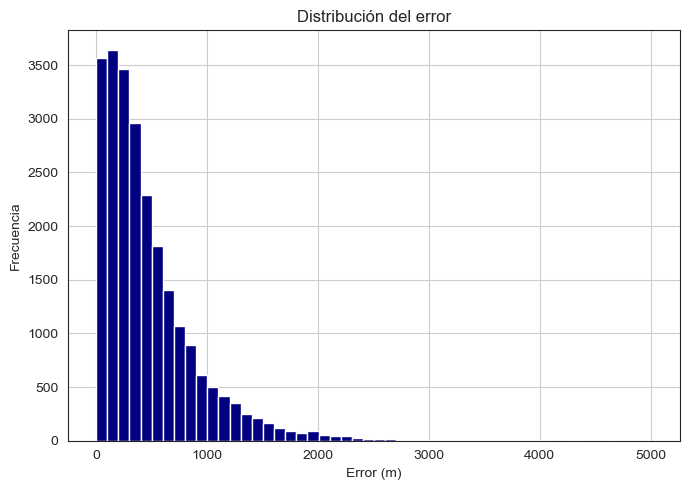

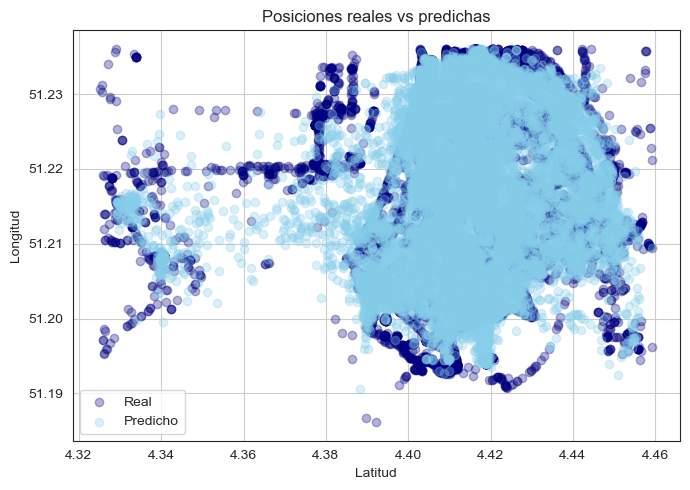

In [72]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_gbr2, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### EXP

In [73]:
start = time.time()
# Definimos el modelo
gbr = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'estimator__n_estimators': [100, 150, 200],
    'estimator__learning_rate': [0.05, 0.7],
    'estimator__max_depth': [9, 11, 13],
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_gbr = GridSearchCV(
    gbr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_gbr.fit(X_train_exp, y_train_scaled)

best_params = grid_gbr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'estimator__learning_rate': 0.05, 'estimator__max_depth': 11, 'estimator__n_estimators': 200}
Tiempo total: 773.18 segundos


In [74]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['estimator__n_estimators']
best_learning_rate = best_params['estimator__learning_rate']
best_max_depth = best_params['estimator__max_depth']

# Entrenamos con la mejor combinación de parámetros
gbr_opt = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42))
gbr_opt.fit(X_train_exp, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 170.81 segundos


In [75]:
start = time.time()

# TRAIN

y_train_pred_scaled = gbr_opt.predict(X_train_exp)
y_train_pred_gbr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_gbr[:, [1, 0]])

dist_train = np.array([
    haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000
#dist_train = haversine_distances(y_true_train_rad, y_pred_train_rad).diagonal() * 6371000

print('TRAIN:')
print(f"GradientBoosting Mean: {dist_train.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = gbr_opt.predict(X_test_exp)
y_test_pred_gbr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_gbr[:, [1, 0]])

dist_test_gbr3 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"GradientBoosting Mean: {dist_test_gbr3.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_test_gbr3):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
GradientBoosting Mean: 344.47
GradientBoosting Median: 256.19

TEST:
GradientBoosting Mean: 475.35
GradientBoosting Median: 349.44
Tiempo total: 23.34 segundos


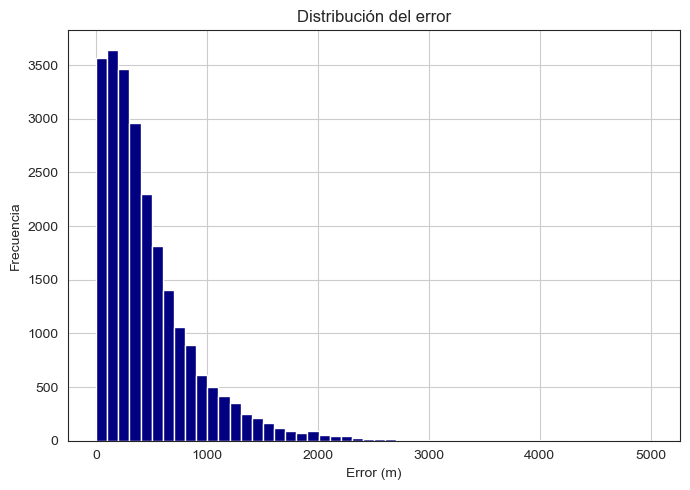

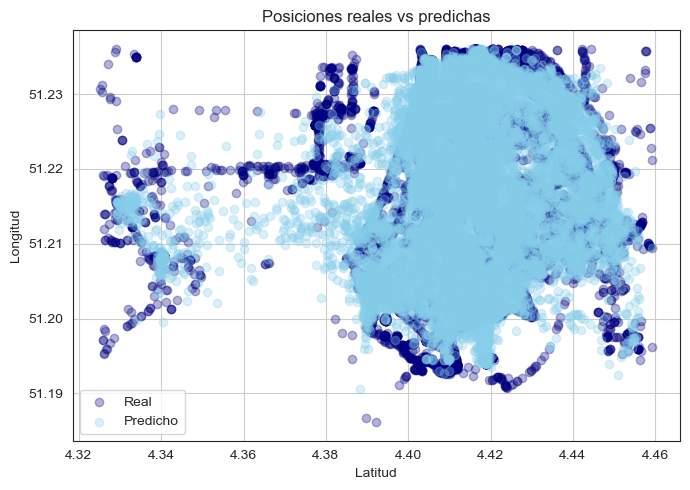

In [76]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_gbr3, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Red neuronal

In [77]:
# Definimos el modelo
mlp = MLPRegressor(
    hidden_layer_sizes=(256,128,64),
    #activation='relu',
    #solver='adam',
    #alpha=0.0001,
    batch_size=256,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

### BASE

In [78]:
start = time.time()

# Entrenamos el modelo
mlp.fit(X_train_base, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 64.67 segundos


In [79]:
start = time.time()

# TRAIN

y_train_pred_scaled = mlp.predict(X_train_base)
y_train_pred_mlp = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_mlp[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"MLP Mean: {dist_train.mean():.2f}")
print(f"MLP Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = mlp.predict(X_test_base)
y_test_pred_mlp = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_mlp[:, [1, 0]])

dist_test_mlp1 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"MLP Mean: {dist_test_mlp1.mean():.2f}")
print(f"MLP Median: {np.median(dist_test_mlp1):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
MLP Mean: 372.34
MLP Median: 271.02

TEST:
MLP Mean: 454.46
MLP Median: 333.77
Tiempo total: 21.49 segundos


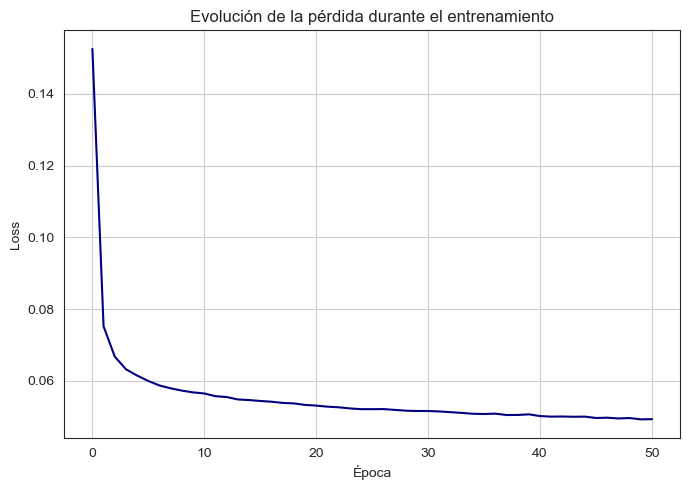

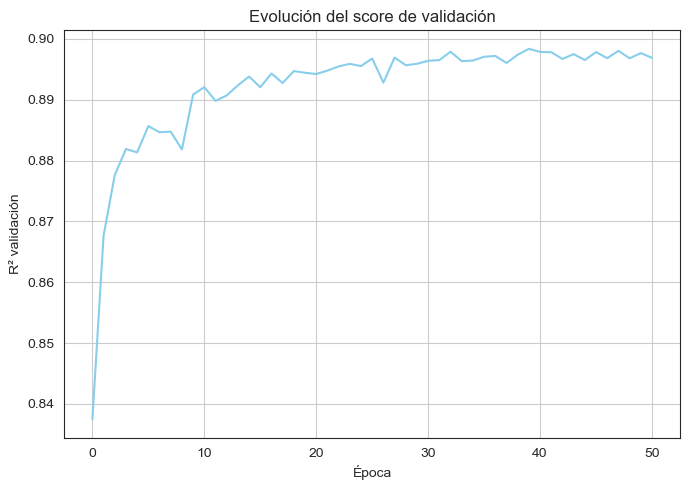

In [80]:
# CURVA DE PÉRDIDA

plt.figure(figsize=(7,5))
plt.plot(mlp.loss_curve_, color="navy")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# VALIDACIÓN

plt.figure(figsize=(7,5))
plt.plot(mlp.validation_scores_, color="skyblue")
plt.title("Evolución del score de validación")
plt.xlabel("Época")
plt.ylabel("R² validación")
plt.grid(True)
plt.tight_layout()
plt.show()

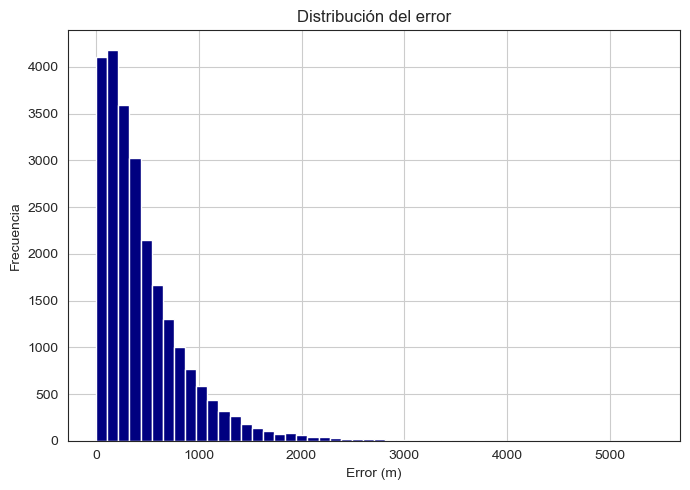

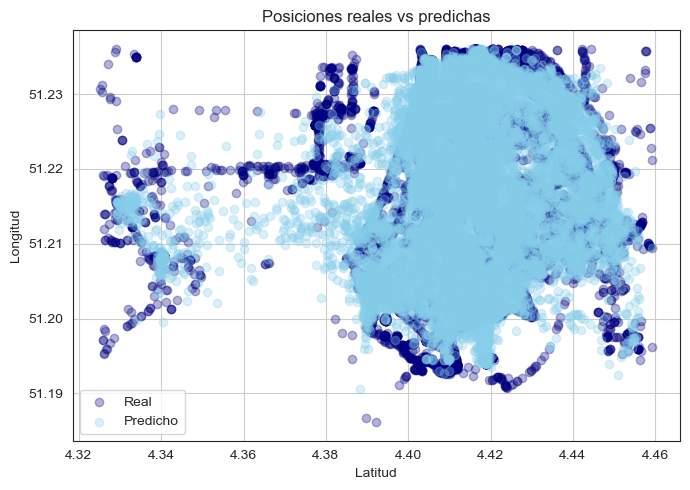

In [81]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_mlp1, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### POW

In [82]:
start = time.time()

# Entrenamos el modelo
mlp.fit(X_train_pow, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 49.85 segundos


In [83]:
start = time.time()

# TRAIN

y_train_pred_scaled = mlp.predict(X_train_pow)
y_train_pred_mlp = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_mlp[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"MLP Mean: {dist_train.mean():.2f}")
print(f"MLP Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = mlp.predict(X_test_pow)
y_test_pred_mlp = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_mlp[:, [1, 0]])

dist_test_mlp2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"MLP Mean: {dist_test_mlp2.mean():.2f}")
print(f"MLP Median: {np.median(dist_test_mlp2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
MLP Mean: 377.95
MLP Median: 273.66

TEST:
MLP Mean: 453.14
MLP Median: 326.35
Tiempo total: 22.30 segundos


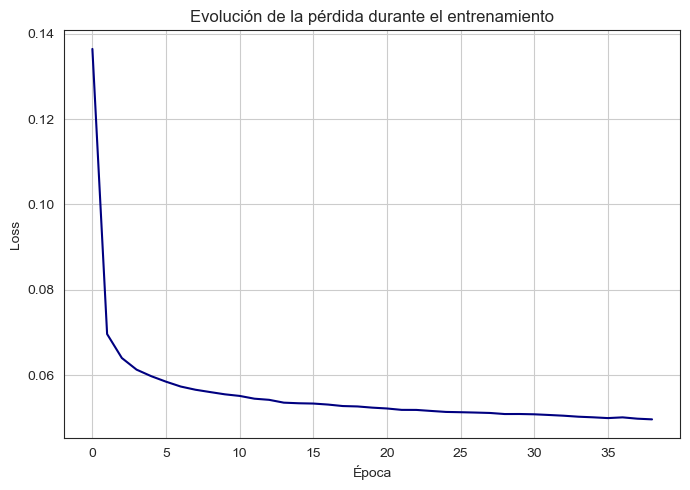

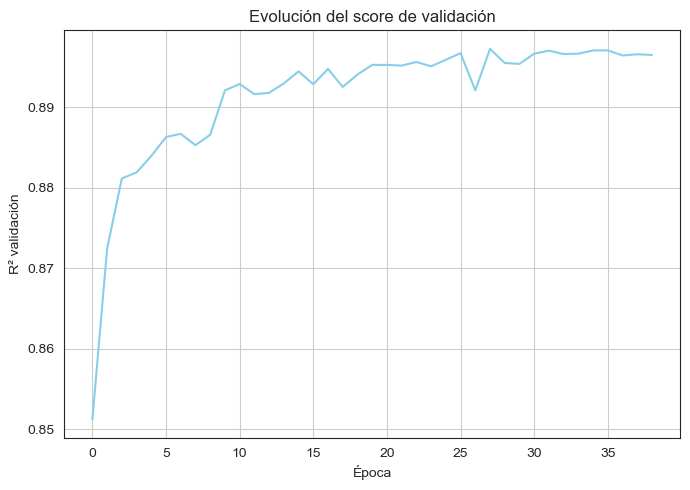

In [84]:
# CURVA DE PÉRDIDA

plt.figure(figsize=(7,5))
plt.plot(mlp.loss_curve_, color="navy")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# VALIDACIÓN

plt.figure(figsize=(7,5))
plt.plot(mlp.validation_scores_, color="skyblue")
plt.title("Evolución del score de validación")
plt.xlabel("Época")
plt.ylabel("R² validación")
plt.grid(True)
plt.tight_layout()
plt.show()

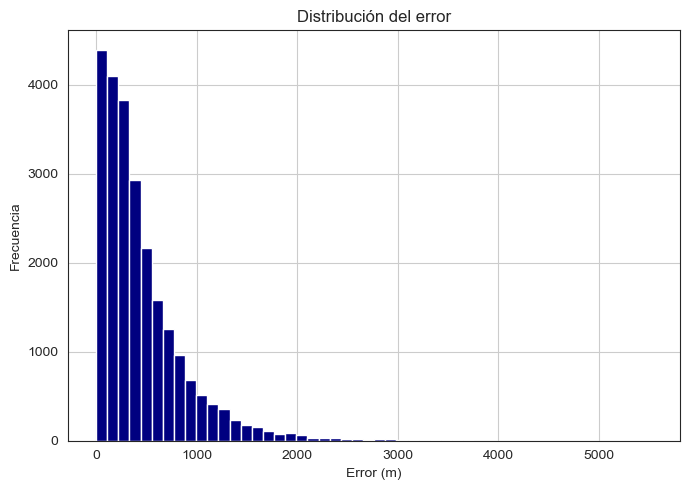

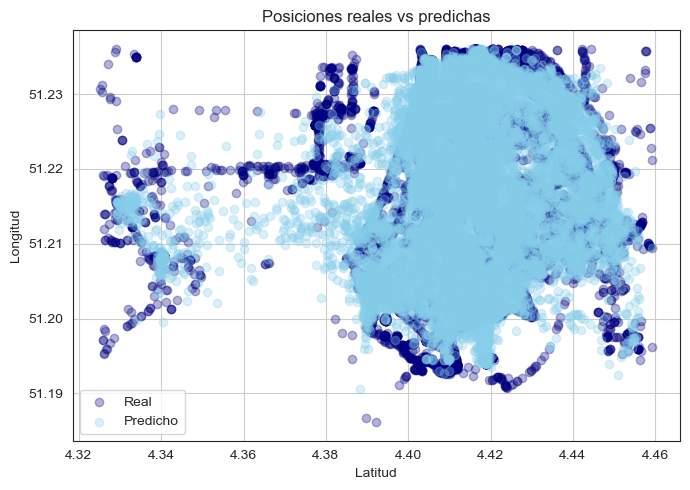

In [85]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_mlp2, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Exp

In [86]:
start = time.time()

# Entrenamos el modelo
mlp.fit(X_train_exp, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 60.17 segundos


In [87]:
start = time.time()

# TRAIN

y_train_pred_scaled = mlp.predict(X_train_exp)
y_train_pred_mlp = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_mlp[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"MLP Mean: {dist_train.mean():.2f}")
print(f"MLP Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = mlp.predict(X_test_exp)
y_test_pred_mlp = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_mlp[:, [1, 0]])

dist_test_mlp3 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"MLP Mean: {dist_test_mlp3.mean():.2f}")
print(f"MLP Median: {np.median(dist_test_mlp3):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
MLP Mean: 437.06
MLP Median: 339.10

TEST:
MLP Mean: 517.69
MLP Median: 400.24
Tiempo total: 21.60 segundos


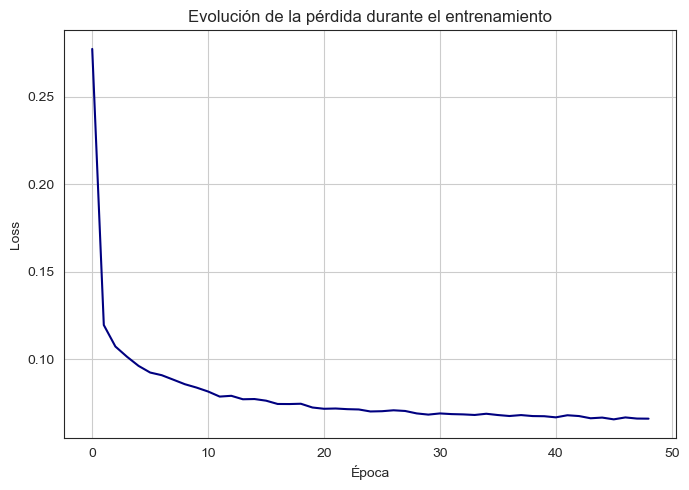

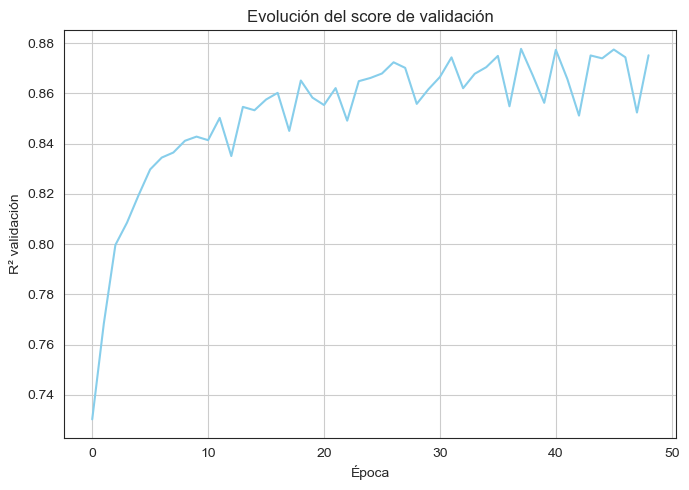

In [88]:
# CURVA DE PÉRDIDA

plt.figure(figsize=(7,5))
plt.plot(mlp.loss_curve_, color="navy")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# VALIDACIÓN

plt.figure(figsize=(7,5))
plt.plot(mlp.validation_scores_, color="skyblue")
plt.title("Evolución del score de validación")
plt.xlabel("Época")
plt.ylabel("R² validación")
plt.grid(True)
plt.tight_layout()
plt.show()

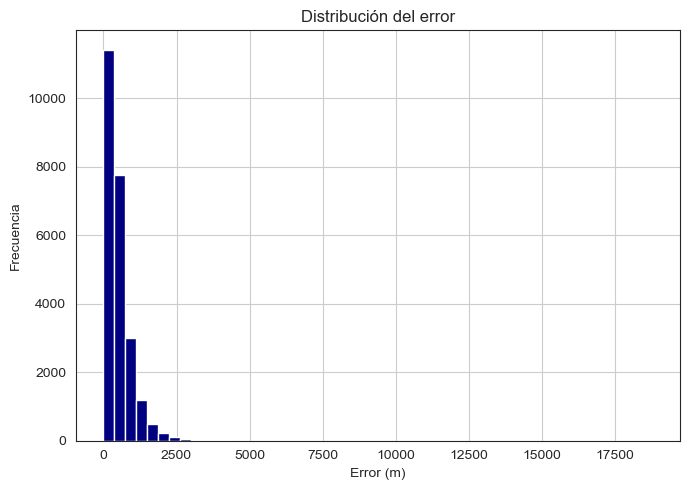

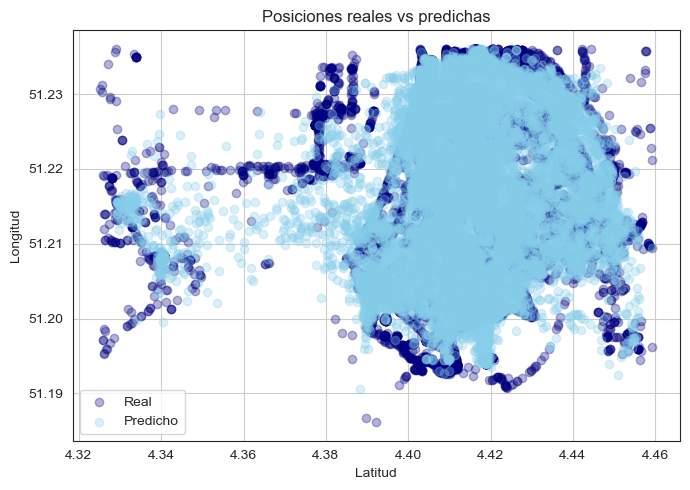

In [89]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_mlp3, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()